### 03a - MIA Attack

Trains the attack classifier on shadow features and evaluates it on target features. Final stage of the MIA pipeline.

#### Inputs
- `outputs/results/mia_features_shadow.csv`
- `outputs/results/mia_features_target.csv`

#### Outputs
- `outputs/results/mia_attack_metrics.csv`
- `outputs/figures/mia_roc_curve.png`

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

Load the feature tables from notebook 02. shadow_df is the attacker's training data (member labels honestly known); target_df is the evaluation data (member labels would be unknown in a real attack).

In [3]:

shadow_df = pd.read_csv("outputs/results/mia_features_shadow.csv")
target_df = pd.read_csv("outputs/results/mia_features_target.csv")

print(f"shadow rows: {len(shadow_df)}  ({shadow_df['member'].sum()} members, {(1-shadow_df['member']).sum()} non-members)")
print(f"target rows: {len(target_df)}  ({target_df['member'].sum()} members, {(1-target_df['member']).sum()} non-members)")

shadow rows: 40000  (32000 members, 8000 non-members)
target rows: 40000  (32000 members, 8000 non-members)


Train logistic regression on shadow features. Evaluate on target features. The class imbalance (4:1 members:non-members) is handled by `class_weight="balanced"` so the classifier doesn't trivially predict "member" for everything.

In [4]:
features = ["prob", "loss"]

X_shadow = shadow_df[features].values
y_shadow = shadow_df["member"].values
X_target = target_df[features].values
y_target = target_df["member"].values

attack = LogisticRegression(class_weight="balanced", max_iter=1000)
attack.fit(X_shadow, y_shadow)

# Predictions on the target set
y_target_prob = attack.predict_proba(X_target)[:, 1]
y_target_pred = (y_target_prob >= 0.5).astype(int)

print(f"Coefficients: prob={attack.coef_[0][0]:+.4f}, loss={attack.coef_[0][1]:+.4f}")
print(f"Intercept:    {attack.intercept_[0]:+.4f}")

Coefficients: prob=-0.1325, loss=-0.1267
Intercept:    +0.1507


Compute attack accuracy, ROC AUC, and TPR at strict FPR thresholds. AUC is the headline metric: 0.50 is random, anything notably higher means membership has leaked. TPR at low FPR matters because real attackers prefer high-confidence hits.

In [ ]:
acc = accuracy_score(y_target, y_target_pred)
auc = roc_auc_score(y_target, y_target_prob)

fpr, tpr, _ = roc_curve(y_target, y_target_prob)
tpr_at_1pct  = np.interp(0.01, fpr, tpr)
tpr_at_10pct = np.interp(0.10, fpr, tpr)

print(f"Attack accuracy:    {acc:.4f}")
print(f"Attack AUC:         {auc:.4f}")
print(f"TPR at FPR=1%:      {tpr_at_1pct:.4f}")
print(f"TPR at FPR=10%:     {tpr_at_10pct:.4f}")

metrics = pd.DataFrame([{
    "attack_accuracy": acc,
    "attack_auc": auc,
    "tpr_at_fpr_1pct":  tpr_at_1pct,
    "tpr_at_fpr_10pct": tpr_at_10pct,
    "coef_prob": attack.coef_[0][0],
    "coef_loss": attack.coef_[0][1],
}])
metrics.to_csv("outputs/results/mia_attack_metrics.csv", index=False)
print("\nSaved: outputs/results/mia_attack_metrics.csv")

Attack accuracy:    0.6733
Attack AUC:         0.5223
TPR at FPR=1%:      0.0103
TPR at FPR=10%:     0.1044

Saved: outputs/results/mia_attack_metrics.csv


ROC curve for the attack. The dashed diagonal is random-guessing. The further the curve bows toward the top-left, the stronger the attack.

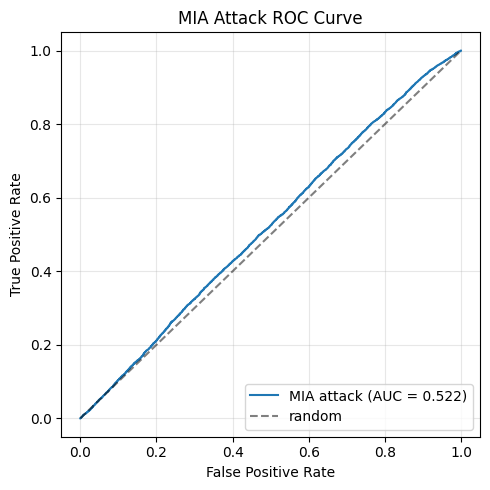

In [ ]:
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"MIA attack (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MIA Attack ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/mia_roc_curve.png", dpi=120)
plt.show()